<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 10px;">
    <h1 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:2.2em; margin:0 0 8px 0;">
        🎓 Introdução ao Aprendizado de Máquina
    </h1>
    <h2 style="color:#a8d8ea; font-family:'Segoe UI', sans-serif; font-size:1.3em; margin:0 0 6px 0; font-weight:400;">
        Aula 08 — Árvore de Decisão
    </h2>
    <h3 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:1.05em; margin:0 0 12px 0; font-weight:500;">
        🔬 Prática — O Modelo que Explica Cada Decisão no Titanic
    </h3>
    <p style="color:#ccc; font-family:'Segoe UI', sans-serif; font-size:0.9em; margin:0;">
       Prof. Felipe Amaral
    </p>
</div>
<div style="display:flex; gap:10px; margin-top:10px; flex-wrap:wrap;">
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">📚 FIAP</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">🐍 Python 3</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">🚢 Dataset Titanic</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">🌳 4º Modelo do Curso</span>
</div>


## Onde estamos?

| Aula | Modelo | Fronteira | Explica a decisão? |
|------|--------|-----------|--------------------|
| 05 | KNN | Local — vizinhos | Não |
| 06 | Reg. Logística | Linear — hiperplano | Sim — coeficientes |
| 07 | SVM | Margem máxima | Parcialmente |
| **08** | **Árvore de Decisão** | **Perguntas encadeadas** | **Sim — cada nó** |

Hoje treinamos o modelo **mais intuitivo** do curso.
Enquanto o SVM resolve um problema de otimização matemática sofisticado,
a Árvore de Decisão faz algo que qualquer pessoa entende:

> *"É mulher? → Sim: provavelmente sobreviveu.*
> *Não: está na 1ª ou 2ª classe? → Sim: alguma chance.*
> *Não: provavelmente não sobreviveu."*

Isso é exatamente o que a árvore aprende — e você consegue
**mostrar para um cliente, médico ou juiz** como cada decisão foi tomada.

---

## Roteiro de hoje

| Parte | Tema |
|-------|------|
| **Config** | Recarregando o Titanic e modelos anteriores |
| **1** | Intuição — como uma árvore toma decisões |
| **2** | Impureza de Gini e Entropia — como escolher a melhor pergunta |
| **3** | Construindo a árvore do zero — passo a passo |
| **4** | Treinando e visualizando a árvore completa |
| **5** | Overfitting e poda — controlando a profundidade |
| **6** | Importância das features e placar geral |

<div style="background:#d4edda; border-left:5px solid #155724; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#155724;">✅ </strong><span style="color:#155724;">A Árvore de Decisão é a base de algoritmos mais poderosos como <strong>Random Forest</strong> e <strong>Gradient Boosting (XGBoost)</strong>, que veremos nas próximas aulas. Entender a árvore individual é o pré-requisito para entender esses modelos.</span></div>

---

## Configuração — Execute antes de começar


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize":  (10, 5),
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     13,
    "axes.labelsize":     11,
})
sns.set_theme(style="whitegrid", palette="muted")

# ── Pipeline completo das aulas anteriores ────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, recall_score, precision_score)

df = sns.load_dataset("titanic").copy()
df["age"]      = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df = df.drop(columns=["deck"]).drop_duplicates().reset_index(drop=True)

df["tamanho_familia"]  = df["sibsp"] + df["parch"] + 1
df["sozinho"]          = (df["tamanho_familia"] == 1).astype(int)
df["faixa_etaria_enc"] = pd.cut(df["age"], bins=[0,12,18,60,100],
                                 labels=[0,1,2,3]).astype(int)
df["tarifa_por_pessoa"]= (df["fare"] / df["tamanho_familia"].clip(lower=1)).round(2)
df["sex_enc"]          = (df["sex"] == "female").astype(int)
df["pclass_enc"]       = df["pclass"].map({1:2, 2:1, 3:0})

embarked_ohe = pd.get_dummies(df["embarked"], prefix="embarked", drop_first=True)
df = pd.concat([df, embarked_ohe], axis=1)

FEATURES = ["pclass_enc","sex_enc","age","tamanho_familia","sozinho",
            "faixa_etaria_enc","tarifa_por_pessoa","embarked_q","embarked_s",
            "titulo_Master","titulo_Miss","titulo_Mr","titulo_Mrs","titulo_Raro"]
FEATURES = [f for f in FEATURES if f in df.columns]

X = df[FEATURES].copy()
y = df["survived"].copy()

# Nota: Árvore de Decisão NÃO precisa de normalização
# Mantemos X_sc para os outros modelos e X_raw para a árvore
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_treino_sc = scaler.fit_transform(X_treino)
X_teste_sc  = scaler.transform(X_teste)

X_treino_arr = X_treino.values
X_teste_arr  = X_teste.values

# Modelos anteriores para comparação final
knn_ref = KNeighborsClassifier(n_neighbors=7).fit(X_treino_sc, y_treino)
lr_ref  = LogisticRegression(max_iter=1000, random_state=42).fit(X_treino_sc, y_treino)
svm_ref = SVC(kernel="rbf", C=1.0, gamma="scale",
              probability=True, random_state=42).fit(X_treino_sc, y_treino)

def metricas(nome, modelo, Xte, yte):
    yp  = modelo.predict(Xte)
    ypr = modelo.predict_proba(Xte)[:,1] if hasattr(modelo,"predict_proba") else None
    return {"Modelo":   nome,
            "Acurácia": accuracy_score(yte, yp),
            "F1":       f1_score(yte, yp),
            "Recall":   recall_score(yte, yp),
            "Precisão": precision_score(yte, yp),
            "AUC-ROC":  roc_auc_score(yte, ypr) if ypr is not None else float("nan")}

print("✅ Dataset e modelos de referência prontos!")
print(f"   Treino: {X_treino_arr.shape[0]} amostras | Teste: {X_teste_arr.shape[0]} amostras")
print()
print("Nota importante:")
print("   A Árvore de Decisão NÃO precisa de normalização — ela usa pontos")
print("   de corte, não distâncias. Treinaremos com X_treino_arr (dados brutos).")


✅ Dataset e modelos de referência prontos!
   Treino: 620 amostras | Teste: 155 amostras

Nota importante:
   A Árvore de Decisão NÃO precisa de normalização — ela usa pontos
   de corte, não distâncias. Treinaremos com X_treino_arr (dados brutos).


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 1</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Intuição — Como uma Árvore Toma Decisões</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"O modelo que qualquer pessoa consegue ler e entender."</p></div></div></div>


### A ideia central

Uma Árvore de Decisão aprende uma sequência de **perguntas binárias** sobre as features.
Em cada nó, ela faz uma pergunta do tipo:

```
"O valor desta feature é maior ou menor que X?"
```

Dependendo da resposta (sim/não), o exemplo vai para o galho da esquerda ou da direita.
No final, chega a uma folha — que contém a classe prevista.

### Vocabulário da árvore

```
                    [No Raiz]
                   sex_enc <= 0.5?
                  /               \
              Sim (homem)       Nao (mulher)
                 /                   \
         [No Interno]            [Folha]
       pclass_enc <= 0.5?    Preve: SOBREVIVEU
          /         \
      Sim            Nao
   [Folha]         [Folha]
 Preve: NAO      Preve: NAO


| Termo | Significado |
|-------|-------------|
| **Nó Raiz** | A primeira pergunta — a feature mais informativa |
| **Nó Interno** | Uma pergunta que divide os dados |
| **Folha** | Nó terminal — contém a previsão final |
| **Profundidade** | Número de perguntas do raiz até a folha mais distante |
| **Poda** | Limitar a profundidade para evitar overfitting |

### A grande vantagem: explicabilidade

O KNN disse "os 7 vizinhos mais próximos votaram assim."
O SVM disse "o ponto está do lado correto do hiperplano."
A Árvore diz: **"Passei por estas 3 perguntas e cheguei nesta resposta."**

Isso é o que se chama de modelo **caixa-branca (white-box)** — você consegue
auditar cada decisão individualmente.


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 1 — Antes de rodar qualquer código, use os dados que você explorou nas aulas anteriores e monte manualmente uma árvore simples de profundidade 2 para o Titanic. Escreva as duas perguntas que você usaria e justifique a escolha. Dica: volte na aula 03 e lembre quais features tinham maior correlação com sobrevivência.</span></div>

*✏️ Minha árvore manual (profundidade 2):*

```
Pergunta 1 (Raiz): ???
    Sim → Pergunta 2a: ???
        Sim → Prevê: ???
        Não → Prevê: ???
    Não → Prevê: ???
```

*Justificativa para essas perguntas: `???`*


In [38]:
# Confirmando na prática: qual é a melhor primeira pergunta?
# A taxa de sobrevivência por cada feature binária nos dá uma pista

print("Taxa de sobrevivência por feature binária — ajuda a montar a árvore manual")
print("=" * 60)

features_binarias = {
    "sex_enc == 1 (mulher)":    df["sex_enc"] == 1,
    "pclass_enc == 2 (1ª cl.)": df["pclass_enc"] == 2,
    "sozinho == 1":             df["sozinho"] == 1,
    "titulo_Mr == 1":           df.get("titulo_Mr", pd.Series(False, index=df.index)) == 1,
    "titulo_Miss == 1":         df.get("titulo_Miss", pd.Series(False, index=df.index)) == 1,
}

for nome, mask in features_binarias.items():
    taxa_sim = df.loc[mask, "survived"].mean()
    taxa_nao = df.loc[~mask, "survived"].mean()
    sep = abs(taxa_sim - taxa_nao)
    print(f"  {nome:<30}  Sim: {taxa_sim:.0%}  Nao: {taxa_nao:.0%}  "
          f"Separacao: {sep:.0%}")

print()
print("Quanto maior a 'Separacao', melhor essa feature como primeira pergunta!")
print("A arvore aprende automaticamente a usar a de maior separacao.")


Taxa de sobrevivência por feature binária — ajuda a montar a árvore manual
  sex_enc == 1 (mulher)           Sim: 74%  Nao: 22%  Separacao: 52%
  pclass_enc == 2 (1ª cl.)        Sim: 63%  Nao: 33%  Separacao: 30%
  sozinho == 1                    Sim: 34%  Nao: 51%  Separacao: 18%
  titulo_Mr == 1                  Sim: nan%  Nao: 41%  Separacao: nan%
  titulo_Miss == 1                Sim: nan%  Nao: 41%  Separacao: nan%

Quanto maior a 'Separacao', melhor essa feature como primeira pergunta!
A arvore aprende automaticamente a usar a de maior separacao.


In [39]:
# ── GABARITO DA MISSÃO 1 (descomente para ver) ───────────────────────────────
# print("Gabarito — Arvore manual:")
# print()
# print("Pergunta 1 (Raiz): sex_enc <= 0.5?  (e homem?)")
# print("  Sim (homem):")
# print("    Pergunta 2a: pclass_enc <= 0.5?  (e 3a classe?)")
# print("      Sim (3a classe) -> Preve: NAO SOBREVIVEU  (taxa historica: ~13%)")
# print("      Nao (1a ou 2a)  -> Preve: NAO SOBREVIVEU  (taxa historica: ~37%)")
# print("  Nao (mulher):")
# print("    -> Preve: SOBREVIVEU  (taxa historica: ~74%)")
# print()
# print("Justificativa:")
# print("  sex_enc tem a maior separacao (~55pp): mulheres sobreviveram muito mais.")
# print("  Para os homens, a classe ainda subdivide bem os grupos.")
# print("  Esse e exatamente o que a arvore treinada aprende!")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 2</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Gini e Entropia — Como Escolher a Melhor Pergunta</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"O algoritmo precisa de um critério matemático para comparar perguntas."</p></div></div></div>


### O problema da escolha

A árvore pode fazer milhares de perguntas diferentes sobre os dados.
Para escolher a **melhor pergunta em cada nó**, ela precisa de uma medida de
**impureza**: o quão misturado está o grupo resultante.

> *Um grupo totalmente puro tem apenas uma classe — é o ideal.*
> *Um grupo 50/50 é completamente impuro — a pior situação.*

### Impureza de Gini

O critério mais comum no scikit-learn:

```
Gini(nó) = 1 − Σ pᵢ²

onde pᵢ = proporção de exemplos da classe i no nó
```

| Situação | Gini |
|----------|------|
| 100% de uma classe | **0.0** — totalmente puro |
| 50% / 50% | **0.5** — máxima impureza |
| 70% / 30% | 1 − (0.7² + 0.3²) = **0.42** |

### Entropia (Information Gain)

Alternativa baseada em teoria da informação:

```
Entropia(nó) = −Σ pᵢ · log₂(pᵢ)
```

| Situação | Entropia |
|----------|---------|
| 100% de uma classe | **0.0 bits** — sem incerteza |
| 50% / 50% | **1.0 bit** — máxima incerteza |

### Ganho de Informação

A árvore escolhe a pergunta que **mais reduz a impureza** nos filhos:

```
Ganho = Impureza(pai) − Σ [ (nᵢ/n) × Impureza(filho i) ]
```

Quanto maior o ganho, melhor a pergunta.


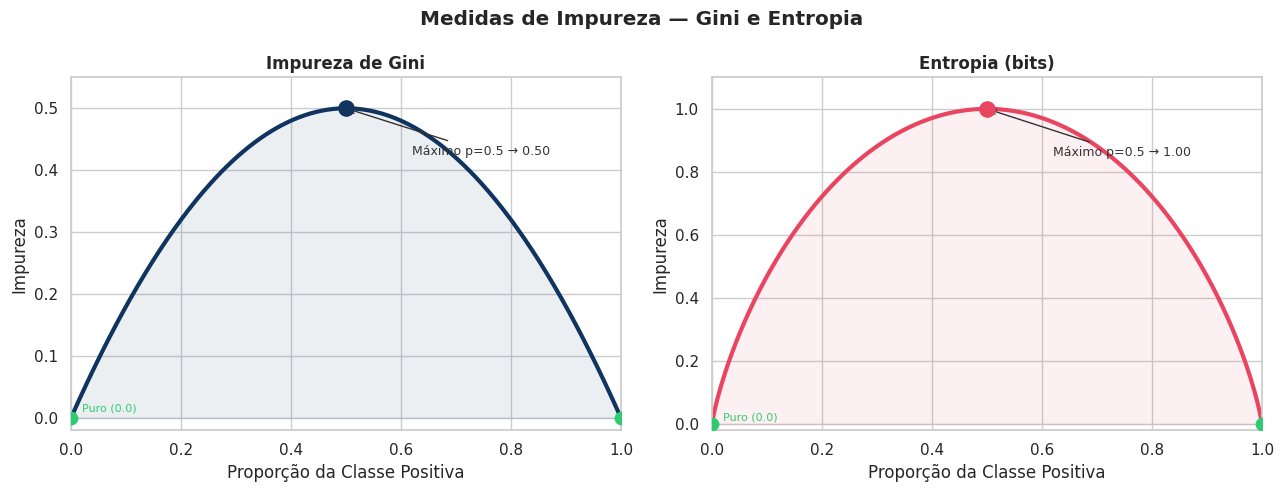

Conclusão: ambas as métricas penalizam grupos misturados.
Gini é mais rápido de calcular; Entropia tende a criar árvores mais balanceadas.


In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Calculando Gini e Entropia para diferentes proporções
proporcoes = np.linspace(0.001, 0.999, 300)

gini     = 1 - (proporcoes**2 + (1-proporcoes)**2)
entropia = -(proporcoes * np.log2(proporcoes) +
             (1-proporcoes) * np.log2(1-proporcoes))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Medidas de Impureza — Gini e Entropia", fontweight="bold")

for ax, vals, titulo, cor, ymax in [
    (axes[0], gini,     "Impureza de Gini",  "#0f3460", 0.55),
    (axes[1], entropia, "Entropia (bits)",   "#e94560", 1.10),
]:
    ax.plot(proporcoes, vals, color=cor, linewidth=3)
    ax.fill_between(proporcoes, vals, alpha=0.08, color=cor)

    # Anotando pontos especiais
    ax.scatter([0.5], [max(vals)], s=120, color=cor, zorder=5)
    ax.annotate(f"Máximo p=0.5 → {max(vals):.2f}",
                xy=(0.5, max(vals)), xytext=(0.62, max(vals)*0.85),
                arrowprops=dict(arrowstyle="->", color="#333"),
                fontsize=9, color="#333")
    ax.scatter([0.0, 1.0], [0, 0], s=80, color="#2ecc71", zorder=5)
    ax.annotate("Puro (0.0)", xy=(0.02, 0.01), fontsize=8, color="#2ecc71")

    ax.set_xlabel("Proporção da Classe Positiva")
    ax.set_ylabel("Impureza")
    ax.set_title(titulo, fontweight="bold")
    ax.set_ylim(-0.02, ymax)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("aula08_impureza.png", dpi=110, bbox_inches="tight")
plt.show()

print("Conclusão: ambas as métricas penalizam grupos misturados.")
print("Gini é mais rápido de calcular; Entropia tende a criar árvores mais balanceadas.")


In [41]:
# Calculando Gini manualmente para uma divisão do Titanic
print("CÁLCULO MANUAL DO GANHO DE GINI")
print("=" * 55)
print()

# Situação: nó raiz com todos os passageiros
total      = len(df)
sobrev     = df["survived"].sum()
nao_sobrev = total - sobrev
p_sobrev   = sobrev / total
p_nao      = nao_sobrev / total

gini_raiz = 1 - (p_sobrev**2 + p_nao**2)
print(f"Nó Raiz (todos os passageiros):")
print(f"  Total:          {total}")
print(f"  Sobreviveram:   {sobrev}  ({p_sobrev:.1%})")
print(f"  Não sobrev.:    {nao_sobrev}  ({p_nao:.1%})")
print(f"  Gini(raiz) = 1 - ({p_sobrev:.3f}² + {p_nao:.3f}²) = {gini_raiz:.4f}")
print()

# Divisão por sex_enc (melhor candidata)
print("Divisão por sex_enc (0=homem, 1=mulher):")
for sexo, nome in [(0,"Homens"),(1,"Mulheres")]:
    grp  = df[df["sex_enc"] == sexo]
    n    = len(grp)
    s    = grp["survived"].sum()
    ns   = n - s
    ps   = s / n
    pns  = ns / n
    gini = 1 - (ps**2 + pns**2)
    peso = n / total
    print(f"  {nome:<10}: n={n:>3} | sobrev={s:>3} ({ps:.0%}) "
          f"| nao_sobrev={ns:>3} ({pns:.0%}) | Gini={gini:.4f} | peso={peso:.3f}")

# Calculando Gini ponderado e Ganho
grp_h = df[df["sex_enc"] == 0]; grp_m = df[df["sex_enc"] == 1]

def gini_no(grp):
    p = grp["survived"].mean()
    return 1 - (p**2 + (1-p)**2)

gini_pond = (len(grp_h)/total)*gini_no(grp_h) + (len(grp_m)/total)*gini_no(grp_m)
ganho     = gini_raiz - gini_pond

print()
print(f"Gini ponderado após a divisão: {gini_pond:.4f}")
print(f"Ganho de Gini: {gini_raiz:.4f} - {gini_pond:.4f} = {ganho:.4f}")
print()
print("Quanto maior o ganho, melhor a divisão!")


CÁLCULO MANUAL DO GANHO DE GINI

Nó Raiz (todos os passageiros):
  Total:          775
  Sobreviveram:   320  (41.3%)
  Não sobrev.:    455  (58.7%)
  Gini(raiz) = 1 - (0.413² + 0.587²) = 0.4848

Divisão por sex_enc (0=homem, 1=mulher):
  Homens    : n=483 | sobrev=104 (22%) | nao_sobrev=379 (78%) | Gini=0.3379 | peso=0.623
  Mulheres  : n=292 | sobrev=216 (74%) | nao_sobrev= 76 (26%) | Gini=0.3851 | peso=0.377

Gini ponderado após a divisão: 0.3557
Ganho de Gini: 0.4848 - 0.3557 = 0.1291

Quanto maior o ganho, melhor a divisão!


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 2 — Calcule o Ganho de Gini para a divisão por <code>pclass_enc</code> (separando classe 3 das demais com corte em 0.5) e compare com o ganho por <code>sex_enc</code>. Qual feature a árvore escolheria como raiz? Complete o código abaixo.</span></div>

In [42]:
# ✏️ Calcule o Ganho de Gini para pclass_enc <= 0.5

# Grupo 1: pclass_enc <= 0.5 (3ª classe)
# grp_3a = df[df["pclass_enc"] <= 0.5]

# Grupo 2: pclass_enc > 0.5 (1ª e 2ª classe)
# grp_12a = df[df["pclass_enc"] > 0.5]

# gini_pond_pclass = ???
# ganho_pclass     = ???

# print(f"Ganho por sex_enc:   {ganho:.4f}")
# print(f"Ganho por pclass:    {ganho_pclass:.4f}")
# print(f"Melhor divisão:      {'sex_enc' if ganho > ganho_pclass else 'pclass_enc'}")

print("Complete o cálculo acima!")


Complete o cálculo acima!


In [43]:
# ── GABARITO DA MISSÃO 2 (descomente para ver) ───────────────────────────────
# grp_3a  = df[df["pclass_enc"] <= 0.5]
# grp_12a = df[df["pclass_enc"] > 0.5]
#
# gini_pond_pclass = ((len(grp_3a) /total) * gini_no(grp_3a) +
#                     (len(grp_12a)/total) * gini_no(grp_12a))
# ganho_pclass = gini_raiz - gini_pond_pclass
#
# print("Comparação de divisões:")
# print(f"  Ganho por sex_enc:    {ganho:.4f}")
# print(f"  Ganho por pclass_enc: {ganho_pclass:.4f}")
# print()
# if ganho > ganho_pclass:
#     print("  Vencedor: sex_enc — a arvore usara essa como raiz!")
#     print("  Faz sentido: a separacao por genero e muito mais limpa")
#     print("  do que por classe social no contexto do Titanic.")
# else:
#     print("  Vencedor: pclass_enc")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 3</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Construindo a Árvore do Zero — Passo a Passo</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Antes de usar a biblioteca, entender o que acontece por dentro."</p></div></div></div>


### O algoritmo CART (Classification and Regression Trees)

O scikit-learn usa o algoritmo **CART** para construir árvores.
Ele é **guloso (greedy)**: em cada nó, escolhe a divisão que
**maximiza o ganho de Gini localmente**, sem olhar para o futuro.

```
CART — Algoritmo:

1. Para cada feature f e cada possível ponto de corte t:
   a. Dividir os dados em esquerda (f ≤ t) e direita (f > t)
   b. Calcular o Ganho de Gini da divisão

2. Escolher o par (f, t) com maior ganho → fazer a divisão

3. Repetir recursivamente em cada filho até:
   - Profundidade máxima atingida, OU
   - Nó com menos que min_samples_split amostras, OU
   - Ganho de Gini = 0 (nó puro)
```


In [44]:
# Implementando o CART simplificado do zero
import numpy as np

def calcular_gini(y):
    # Calcula a impureza de Gini de um array de classes.
    if len(y) == 0:
        return 0.0
    classes, counts = np.unique(y, return_counts=True)
    proporcoes = counts / len(y)
    return 1.0 - np.sum(proporcoes ** 2)

def melhor_divisao(X, y):
    # Encontra a melhor feature e ponto de corte pelo Ganho de Gini.
    gini_pai   = calcular_gini(y)
    n_total    = len(y)
    melhor_ganho = 0.0
    melhor_feat  = None
    melhor_corte = None

    for feat_idx in range(X.shape[1]):
        valores = np.unique(X[:, feat_idx])
        pontos_de_corte = (valores[:-1] + valores[1:]) / 2  # pontos médios

        for corte in pontos_de_corte:
            mask_esq = X[:, feat_idx] <= corte
            mask_dir = ~mask_esq
            y_esq, y_dir = y[mask_esq], y[mask_dir]

            if len(y_esq) == 0 or len(y_dir) == 0:
                continue

            gini_pond = (len(y_esq)/n_total * calcular_gini(y_esq) +
                         len(y_dir)/n_total * calcular_gini(y_dir))
            ganho = gini_pai - gini_pond

            if ganho > melhor_ganho:
                melhor_ganho = ganho
                melhor_feat  = feat_idx
                melhor_corte = corte

    return melhor_feat, melhor_corte, melhor_ganho


# Testando com os dados do Titanic — apenas as 3 primeiras features para agilidade
X_demo = X_treino_arr[:, :3]   # pclass_enc, sex_enc, age
y_demo = y_treino.values

feat_idx, corte, ganho = melhor_divisao(X_demo, y_demo)
nomes_demo = FEATURES[:3]

print("CART DO ZERO — Encontrando a melhor divisão")
print("=" * 50)
print(f"Gini do nó raiz: {calcular_gini(y_demo):.4f}")
print()
print(f"Melhor feature:      {nomes_demo[feat_idx]} (índice {feat_idx})")
print(f"Melhor corte:        ≤ {corte:.4f}")
print(f"Ganho de Gini:       {ganho:.4f}")
print()
print("Verificação: qual feature é essa?")
print(f"  {nomes_demo[feat_idx]} = {'sex_enc (gênero)' if nomes_demo[feat_idx]=='sex_enc' else nomes_demo[feat_idx]}")


CART DO ZERO — Encontrando a melhor divisão
Gini do nó raiz: 0.4848

Melhor feature:      sex_enc (índice 1)
Melhor corte:        ≤ 0.5000
Ganho de Gini:       0.1364

Verificação: qual feature é essa?
  sex_enc = sex_enc (gênero)


In [45]:
# Simulando as primeiras 3 divisões da árvore manualmente
print("SIMULAÇÃO — Primeiras 3 divisões da Árvore CART")
print("=" * 60)

def descrever_no(X, y, features, nivel=0, max_nivel=3, prefix=""):
    indent = "  " * nivel
    gini   = calcular_gini(y)
    n      = len(y)
    n_sob  = y.sum()
    classe = "SOBREVIVEU ✅" if n_sob/n > 0.5 else "NAO SOBREVIVEU ❌"

    print(f"{indent}{prefix}n={n} | Sobrev={n_sob} ({n_sob/n:.0%}) | "
          f"Gini={gini:.3f} → Prevê: {classe}")

    if nivel >= max_nivel or gini == 0 or n < 10:
        return

    feat_idx, corte, ganho = melhor_divisao(X, y)
    if feat_idx is None:
        return

    feat_nome = features[feat_idx]
    print(f"{indent}└─ Pergunta: {feat_nome} <= {corte:.2f}? (Ganho={ganho:.4f})")

    mask_esq = X[:, feat_idx] <= corte
    mask_dir = ~mask_esq

    if mask_esq.sum() > 0:
        descrever_no(X[mask_esq], y[mask_esq], features, nivel+1,
                     max_nivel, prefix="[SIM] ")
    if mask_dir.sum() > 0:
        descrever_no(X[mask_dir], y[mask_dir], features, nivel+1,
                     max_nivel, prefix="[NAO] ")

descrever_no(X_demo, y_demo, nomes_demo, max_nivel=2)


SIMULAÇÃO — Primeiras 3 divisões da Árvore CART
n=620 | Sobrev=256 (41%) | Gini=0.485 → Prevê: NAO SOBREVIVEU ❌
└─ Pergunta: sex_enc <= 0.50? (Ganho=0.1364)
  [SIM] n=382 | Sobrev=79 (21%) | Gini=0.328 → Prevê: NAO SOBREVIVEU ❌
  └─ Pergunta: age <= 6.50? (Ganho=0.0209)
    [SIM] n=18 | Sobrev=12 (67%) | Gini=0.444 → Prevê: SOBREVIVEU ✅
    [NAO] n=364 | Sobrev=67 (18%) | Gini=0.300 → Prevê: NAO SOBREVIVEU ❌
  [NAO] n=238 | Sobrev=177 (74%) | Gini=0.381 → Prevê: SOBREVIVEU ✅
  └─ Pergunta: pclass_enc <= 0.50? (Ganho=0.1029)
    [SIM] n=106 | Sobrev=52 (49%) | Gini=0.500 → Prevê: NAO SOBREVIVEU ❌
    [NAO] n=132 | Sobrev=125 (95%) | Gini=0.100 → Prevê: SOBREVIVEU ✅


<div style="background:#e8d5f5; border-left:5px solid #5b2c8d; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#5b2c8d;">💡 </strong><span style="color:#5b2c8d;">O algoritmo que você implementou acima é exatamente o que o scikit-learn executa internamente — com otimizações em Cython para ser muito mais rápido. A lógica, porém, é a mesma: Gini guloso, divisão binária, recursão.</span></div>

---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 4</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Treinando e Visualizando a Árvore Completa</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"A grande vantagem: você pode mostrar a árvore para qualquer pessoa."</p></div></div></div>


### Importante: Árvore de Decisão não precisa de normalização!

Ao contrário do KNN e do SVM, a Árvore de Decisão usa **pontos de corte**,
não distâncias. Portanto:
- Normalização não muda o resultado
- Encoding ordinal é suficiente para variáveis categóricas
- One-Hot Encoding ainda é útil para garantir que o modelo veja as categorias corretamente


In [46]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# ── Treinando com profundidade 3 — boa para visualizar ───────────────────────
arvore_viz = DecisionTreeClassifier(
    max_depth=3,
    criterion="gini",
    random_state=42
)
arvore_viz.fit(X_treino_arr, y_treino)

print("Árvore treinada (profundidade=3)!")
print(f"  Nós totais:        {arvore_viz.tree_.node_count}")
print(f"  Nós folha:         {arvore_viz.get_n_leaves()}")
print(f"  Profundidade real: {arvore_viz.get_depth()}")
print(f"  Acurácia treino:   {arvore_viz.score(X_treino_arr, y_treino):.1%}")
print(f"  Acurácia teste:    {arvore_viz.score(X_teste_arr,  y_teste):.1%}")


Árvore treinada (profundidade=3)!
  Nós totais:        15
  Nós folha:         8
  Profundidade real: 3
  Acurácia treino:   81.1%
  Acurácia teste:    80.0%


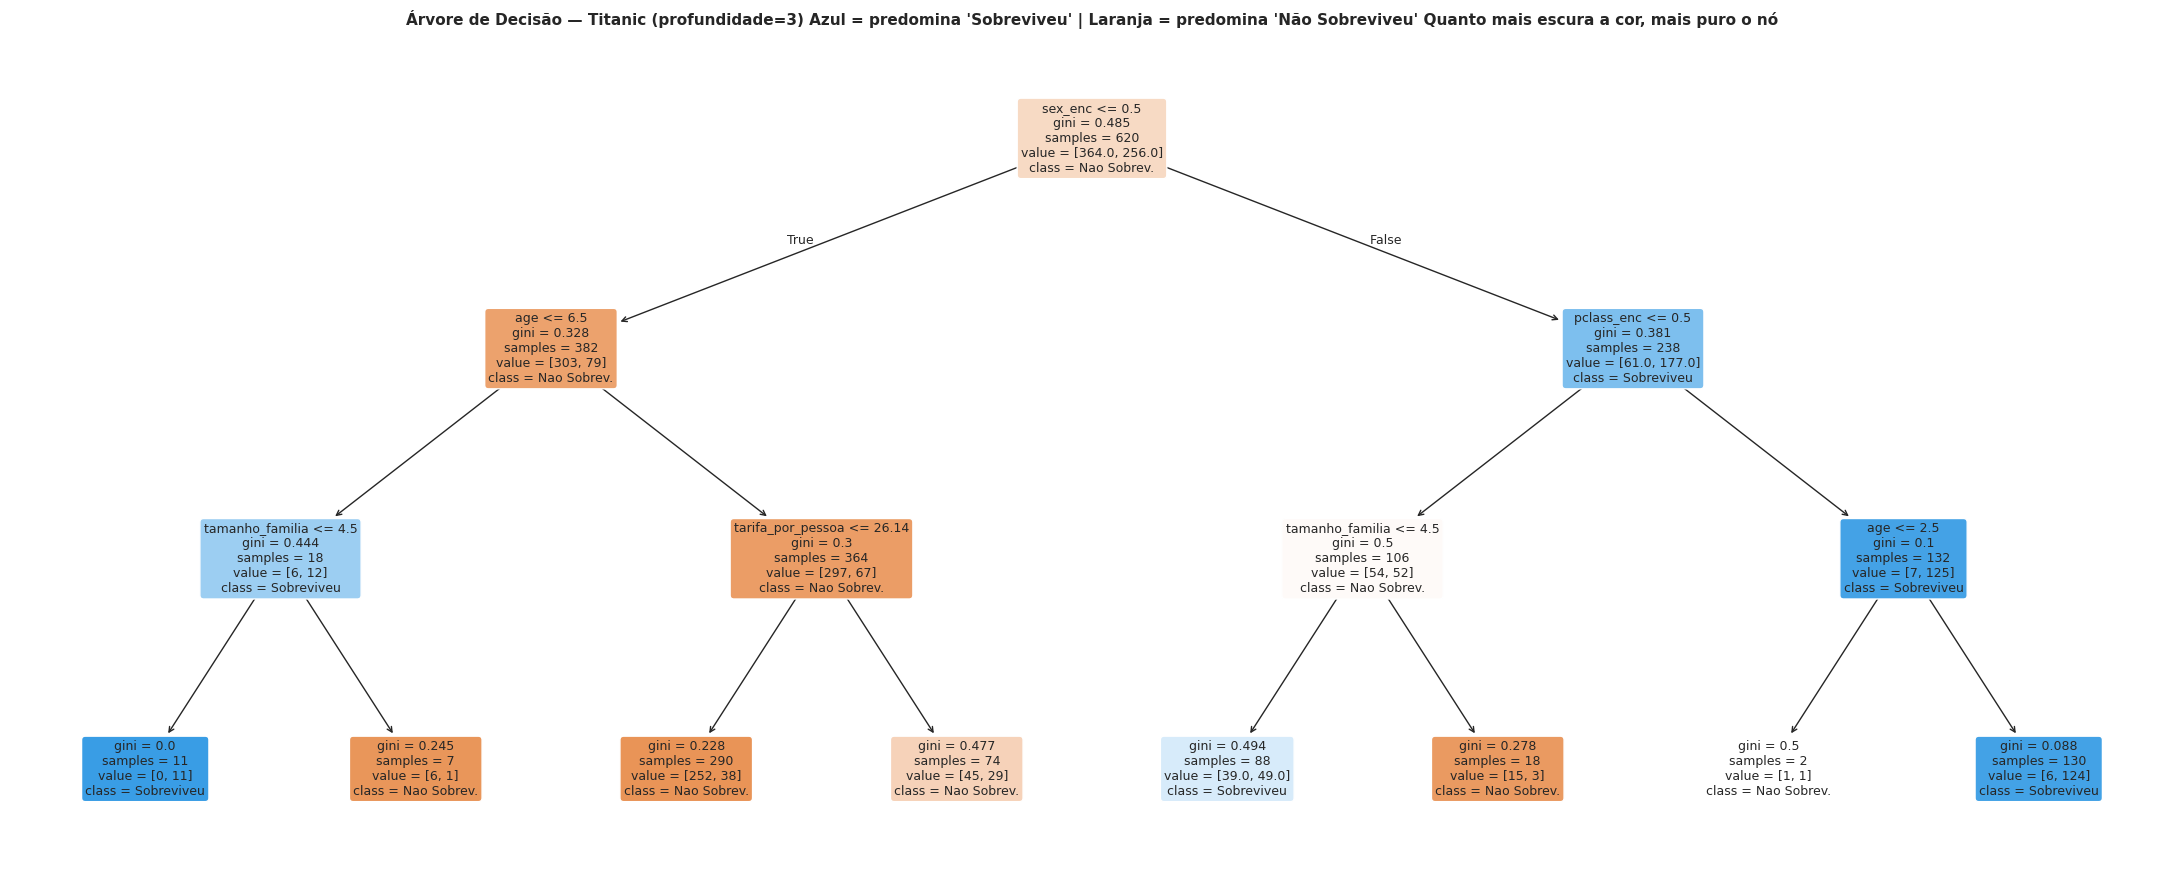

In [47]:
# Visualizando a árvore — o grande diferencial do algoritmo
fig, ax = plt.subplots(figsize=(22, 9))

plot_tree(
    arvore_viz,
    feature_names=FEATURES,
    class_names=["Nao Sobrev.", "Sobreviveu"],
    filled=True,          # cores por classe predominante
    rounded=True,         # cantos arredondados
    impurity=True,        # mostra Gini de cada nó
    proportion=False,     # mostra contagens absolutas
    fontsize=9,
    ax=ax,
)

ax.set_title( "Árvore de Decisão — Titanic (profundidade=3) Azul = predomina 'Sobreviveu' | Laranja = predomina 'Não Sobreviveu' Quanto mais escura a cor, mais puro o nó",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("aula08_arvore_viz.png", dpi=110, bbox_inches="tight")
plt.show()


In [48]:
# Versão texto da árvore — útil para relatórios e auditoria
print("ÁRVORE EM FORMATO TEXTO (profundidade=3)")
print("=" * 60)
texto = export_text(arvore_viz, feature_names=FEATURES)
print(texto)


ÁRVORE EM FORMATO TEXTO (profundidade=3)
|--- sex_enc <= 0.50
|   |--- age <= 6.50
|   |   |--- tamanho_familia <= 4.50
|   |   |   |--- class: 1
|   |   |--- tamanho_familia >  4.50
|   |   |   |--- class: 0
|   |--- age >  6.50
|   |   |--- tarifa_por_pessoa <= 26.14
|   |   |   |--- class: 0
|   |   |--- tarifa_por_pessoa >  26.14
|   |   |   |--- class: 0
|--- sex_enc >  0.50
|   |--- pclass_enc <= 0.50
|   |   |--- tamanho_familia <= 4.50
|   |   |   |--- class: 1
|   |   |--- tamanho_familia >  4.50
|   |   |   |--- class: 0
|   |--- pclass_enc >  0.50
|   |   |--- age <= 2.50
|   |   |   |--- class: 0
|   |   |--- age >  2.50
|   |   |   |--- class: 1



In [49]:
# Rastreando a decisão para um passageiro específico
print("RASTREANDO A DECISÃO — Passageiro do conjunto de teste")
print("=" * 58)

# Escolhendo um passageiro interessante
idx = 10
passageiro = X_teste_arr[idx]
real        = y_teste.values[idx]

print(f"Passageiro #{idx} — features:")
for feat, val in zip(FEATURES, passageiro):
    print(f"  {feat:<22}: {val:.3f}")
print()

# Seguindo o caminho na árvore
node_indicator = arvore_viz.decision_path(passageiro.reshape(1,-1))
leaf_id        = arvore_viz.apply(passageiro.reshape(1,-1))
threshold      = arvore_viz.tree_.threshold
feature_arr    = arvore_viz.tree_.feature

print("Caminho percorrido na árvore:")
for node_id in node_indicator.indices:
    if leaf_id[0] == node_id:
        classe = "Sobreviveu" if arvore_viz.predict(passageiro.reshape(1,-1))[0]==1                  else "Nao Sobreviveu"
        print(f"  -> FOLHA: Previsao = {classe}")
    else:
        feat_nome = FEATURES[feature_arr[node_id]]
        corte     = threshold[node_id]
        val       = passageiro[feature_arr[node_id]]
        direcao   = "<= (SIM, vai para ESQ)" if val <= corte else "> (NAO, vai para DIR)"
        print(f"  Nó {node_id:>3}: {feat_nome} <= {corte:.3f}? "
              f"Valor={val:.3f} → {direcao}")

print()
print(f"Resultado real: {'Sobreviveu ✅' if real==1 else 'Nao Sobreviveu ❌'}")
print(f"Previsao:       {'Sobreviveu ✅' if arvore_viz.predict(passageiro.reshape(1,-1))[0]==1 else 'Nao Sobreviveu ❌'}")


RASTREANDO A DECISÃO — Passageiro do conjunto de teste
Passageiro #10 — features:
  pclass_enc            : 2.000
  sex_enc               : 0.000
  age                   : 28.000
  tamanho_familia       : 1.000
  sozinho               : 1.000
  faixa_etaria_enc      : 2.000
  tarifa_por_pessoa     : 29.700

Caminho percorrido na árvore:
  Nó   0: sex_enc <= 0.500? Valor=0.000 → <= (SIM, vai para ESQ)
  Nó   1: age <= 6.500? Valor=28.000 → > (NAO, vai para DIR)
  Nó   5: tarifa_por_pessoa <= 26.140? Valor=29.700 → > (NAO, vai para DIR)
  -> FOLHA: Previsao = Nao Sobreviveu

Resultado real: Sobreviveu ✅
Previsao:       Nao Sobreviveu ❌


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 3 — Olhando para a árvore visualizada, responda: (a) qual foi a primeira pergunta da árvore (nó raiz)? Corresponde à sua hipótese da Missão 1? (b) em qual folha a maioria dos homens de 3ª classe termina? (c) existe algum nó com Gini=0.0? O que isso significa?</span></div>

*✏️ (a) Primeiro nó (raiz): `???` — corresponde à minha hipótese? `???`*

*✏️ (b) Homens de 3ª classe terminam na folha que prevê: `???`*

*✏️ (c) Existe nó com Gini=0? `???` — isso significa: `???`*


In [50]:
# ── GABARITO DA MISSÃO 3 (descomente para ver) ───────────────────────────────
# print("Gabarito:")
# print()
# print("(a) Primeiro nó (raiz):")
# print(f"    Feature: {FEATURES[arvore_viz.tree_.feature[0]]}")
# print(f"    Corte:   <= {arvore_viz.tree_.threshold[0]:.3f}")
# print("    Isso corresponde a perguntar pelo genero do passageiro.")
# print("    Deve corresponder a hipotese da Missao 1 — sex_enc e a melhor divisao.")
# print()
# print("(b) Homens de 3a classe:")
# print("    Passam pela divisao de genero (sao homens: SIM)")
# print("    Depois pela divisao de classe (3a classe: SIM)")
# print("    Terminam na folha: NAO SOBREVIVEU (taxa historica ~13%)")
# print()
# print("(c) Nos com Gini=0.0:")
# print("    Sao nos completamente puros — todos os exemplos sao da mesma classe.")
# print("    Significa que a arvore encontrou um subgrupo 100% separado.")
# print("    Cuidado: com dados de treino isso pode indicar overfitting!")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 5</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Overfitting e Poda — Controlando a Profundidade</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Uma árvore muito funda decora o treino. Uma muito rasa ignora os padrões."</p></div></div></div>


### O problema do overfitting em árvores

Uma árvore sem limitação de profundidade pode crescer até ter
**uma folha por exemplo** — acerto de 100% no treino e péssimo no teste.

```
Profundidade 1:  muito simples → underfitting
Profundidade 3:  balanceado   → bom para generalizar  ✅
Profundidade 20: muito fundo  → overfitting
```

### Parâmetros de controle (poda preventiva)

| Parâmetro | O que controla |
|-----------|---------------|
| `max_depth` | Profundidade máxima da árvore |
| `min_samples_split` | Mínimo de exemplos para dividir um nó |
| `min_samples_leaf` | Mínimo de exemplos em cada folha |
| `max_features` | Número máximo de features testadas por divisão |
| `ccp_alpha` | Poda por custo-complexidade (pós-treinamento) |


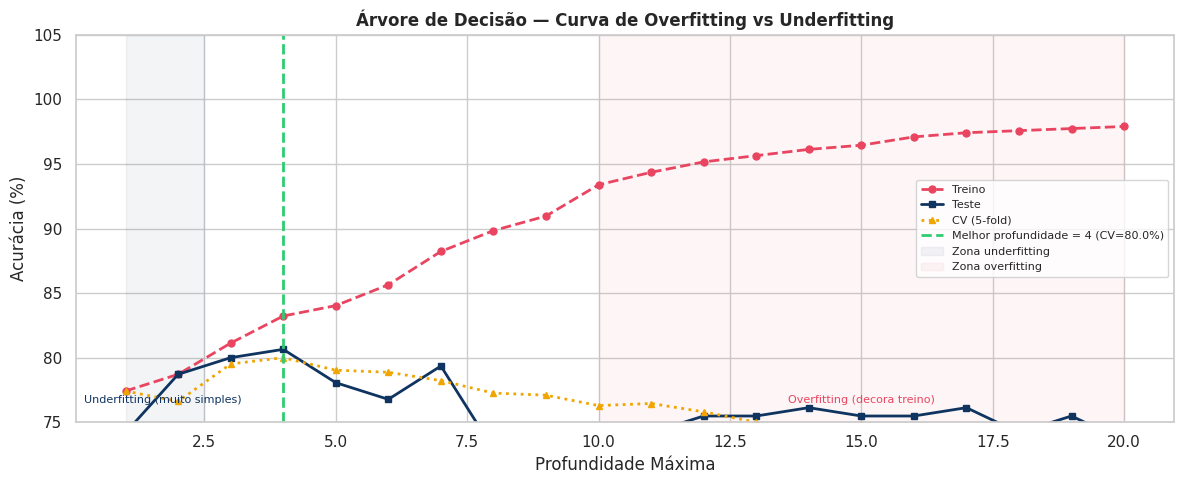

Melhor profundidade (CV): 4
Acurácia treino na profund. 4:  83.2%
Acurácia teste  na profund. 4:  80.6%
Diferença treino-teste:     +2.6pp


In [51]:
from sklearn.model_selection import cross_val_score

# Curva de profundidade: treino vs teste
profundidades    = range(1, 21)
accs_treino      = []
accs_teste       = []
accs_cv          = []

for d in profundidades:
    arvore_d = DecisionTreeClassifier(
        max_depth=d, criterion="gini", random_state=42)
    arvore_d.fit(X_treino_arr, y_treino)
    accs_treino.append(arvore_d.score(X_treino_arr, y_treino))
    accs_teste.append(arvore_d.score(X_teste_arr,   y_teste))
    cv = cross_val_score(arvore_d, X_treino_arr, y_treino, cv=5).mean()
    accs_cv.append(cv)

melhor_d   = list(profundidades)[np.argmax(accs_cv)]
melhor_acc = max(accs_cv)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(profundidades, [a*100 for a in accs_treino], "o--",
        color="#e94560", linewidth=2, markersize=5, label="Treino")
ax.plot(profundidades, [a*100 for a in accs_teste],  "s-",
        color="#0f3460", linewidth=2, markersize=5, label="Teste")
ax.plot(profundidades, [a*100 for a in accs_cv],     "^:",
        color="#f0a500", linewidth=2, markersize=5, label="CV (5-fold)")

ax.axvline(melhor_d, color="#2ecc71", linestyle="--", linewidth=2,
           label=f"Melhor profundidade = {melhor_d} (CV={melhor_acc:.1%})")

ax.fill_betweenx([75, 105], 1, 2.5,  alpha=0.05, color="#0f3460",
                  label="Zona underfitting")
ax.fill_betweenx([75, 105], 10, 20,  alpha=0.05, color="#e94560",
                  label="Zona overfitting")
ax.annotate("Underfitting (muito simples)", xy=(1.7, 76.5),
            fontsize=8, color="#0f3460", ha="center")
ax.annotate("Overfitting (decora treino)", xy=(15, 76.5),
            fontsize=8, color="#e94560", ha="center")

ax.set_xlabel("Profundidade Máxima")
ax.set_ylabel("Acurácia (%)")
ax.set_title("Árvore de Decisão — Curva de Overfitting vs Underfitting",
             fontweight="bold")
ax.legend(fontsize=8); ax.set_ylim(75, 105)
plt.tight_layout()
plt.savefig("aula08_overfitting.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"Melhor profundidade (CV): {melhor_d}")
print(f"Acurácia treino na profund. {melhor_d}:  {accs_treino[melhor_d-1]:.1%}")
print(f"Acurácia teste  na profund. {melhor_d}:  {accs_teste[melhor_d-1]:.1%}")
print(f"Diferença treino-teste:     {(accs_treino[melhor_d-1]-accs_teste[melhor_d-1])*100:+.1f}pp")


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 4 — Olhando para a curva gerada, responda: (a) a partir de qual profundidade o modelo começa claramente a overfit? (b) qual é a diferença de acurácia entre treino e teste em profundidade=15? (c) por que a linha de CV (validação cruzada) é mais confiável que a linha de Teste para escolher a profundidade ideal?</span></div>

*✏️ (a) Overfitting começa a partir de profundidade: `???`*

*✏️ (b) Diferença treino-teste em d=15: `???`*

*✏️ (c) CV é mais confiável porque: `???`*


In [52]:
# ── GABARITO DA MISSÃO 4 (descomente para ver) ───────────────────────────────
# print("Gabarito:")
# print()
# d15_treino = accs_treino[14]
# d15_teste  = accs_teste[14]
# print(f"(a) Overfitting claro a partir de profundidade ~{melhor_d + 2}")
# print("    A linha de treino continua subindo enquanto a de teste cai.")
# print()
# print(f"(b) Profundidade 15:")
# print(f"    Treino: {d15_treino:.1%}  |  Teste: {d15_teste:.1%}")
# print(f"    Diferenca: {(d15_treino - d15_teste)*100:.1f}pp — sinal classico de overfitting")
# print()
# print("(c) CV e mais confiavel porque:")
# print("    Ela usa DIFERENTES partes dos dados de treino para validar.")
# print("    Um unico split treino/teste pode ter 'sorte' ou 'azar' dependendo")
# print("    de quais exemplos caem em cada parte.")
# print("    O CV avalia em 5 splits diferentes e tira a media — muito mais estavel.")


In [53]:
# Treinando a árvore final com a melhor profundidade encontrada
arvore_final = DecisionTreeClassifier(
    max_depth=melhor_d,
    criterion="gini",
    min_samples_leaf=5,
    random_state=42
)
arvore_final.fit(X_treino_arr, y_treino)

from sklearn.metrics import classification_report
y_pred_arvore = arvore_final.predict(X_teste_arr)

print(f"ÁRVORE FINAL (max_depth={melhor_d}, min_samples_leaf=5)")
print("=" * 50)
print(classification_report(y_teste, y_pred_arvore,
      target_names=["Nao Sobreviveu","Sobreviveu"]))


ÁRVORE FINAL (max_depth=4, min_samples_leaf=5)
                precision    recall  f1-score   support

Nao Sobreviveu       0.84      0.82      0.83        91
    Sobreviveu       0.76      0.78      0.77        64

      accuracy                           0.81       155
     macro avg       0.80      0.80      0.80       155
  weighted avg       0.81      0.81      0.81       155



---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 6</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Importância das Features e Placar Final</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"A árvore nos diz não só o que previu, mas quais features mais importaram."</p></div></div></div>


### Feature Importance na Árvore de Decisão

A importância de cada feature é calculada pela **redução total de Gini** que ela
proporcionou ao longo de todas as divisões da árvore:

```
Importância(feature) = Σ [ganho_de_gini × proporção de amostras] em todos os nós que usam essa feature
```

Quanto mais vezes uma feature é usada, e quanto maior o ganho que ela traz,
maior sua importância. O resultado é normalizado para somar 1.


Importância das Features — Árvore de Decisão
          feature  importancia
          sex_enc       0.5759
       pclass_enc       0.1669
tarifa_por_pessoa       0.0998
              age       0.0836
  tamanho_familia       0.0738
          sozinho       0.0000
 faixa_etaria_enc       0.0000


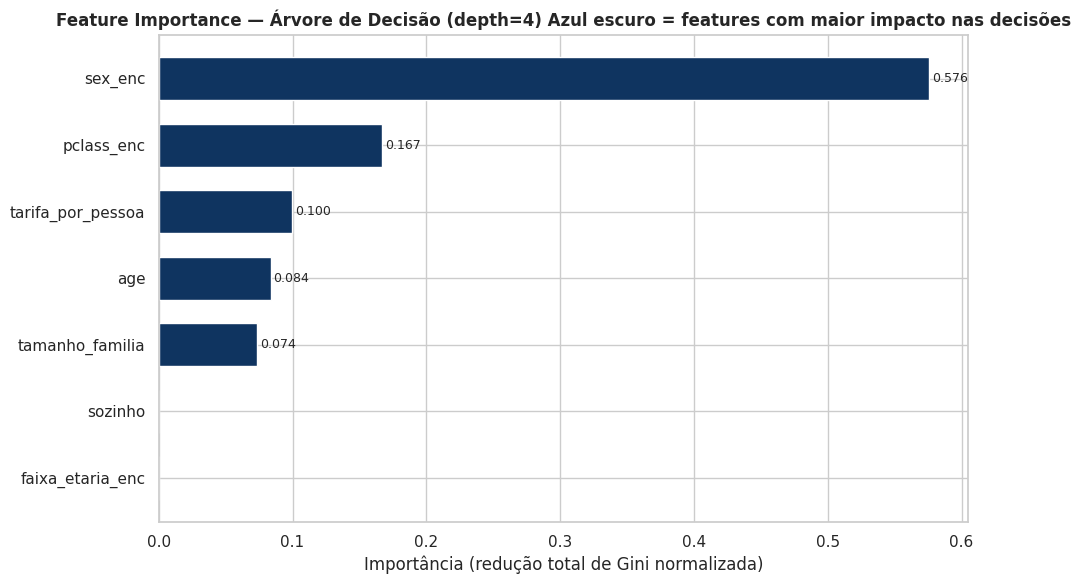

In [54]:
# Feature importance da árvore final
importancias = pd.DataFrame({
    "feature":     FEATURES,
    "importancia": arvore_final.feature_importances_
}).sort_values("importancia", ascending=False)

print("Importância das Features — Árvore de Decisão")
print("=" * 50)
print(importancias.round(4).to_string(index=False))

# Gráfico de importância
fig, ax = plt.subplots(figsize=(10, 6))

cores_imp = ["#0f3460" if v > 0.05 else "#a8d8ea"
             for v in importancias["importancia"]]
barras = ax.barh(
    importancias["feature"],
    importancias["importancia"],
    color=cores_imp, edgecolor="white", height=0.65
)
for b, v in zip(barras, importancias["importancia"]):
    if v > 0.005:
        ax.text(v + 0.002, b.get_y() + b.get_height()/2,
                f"{v:.3f}", va="center", fontsize=9)

ax.set_xlabel("Importância (redução total de Gini normalizada)")
ax.set_title(f"Feature Importance — Árvore de Decisão (depth={melhor_d}) "
             "Azul escuro = features com maior impacto nas decisões",
             fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("aula08_feature_importance.png", dpi=110, bbox_inches="tight")
plt.show()


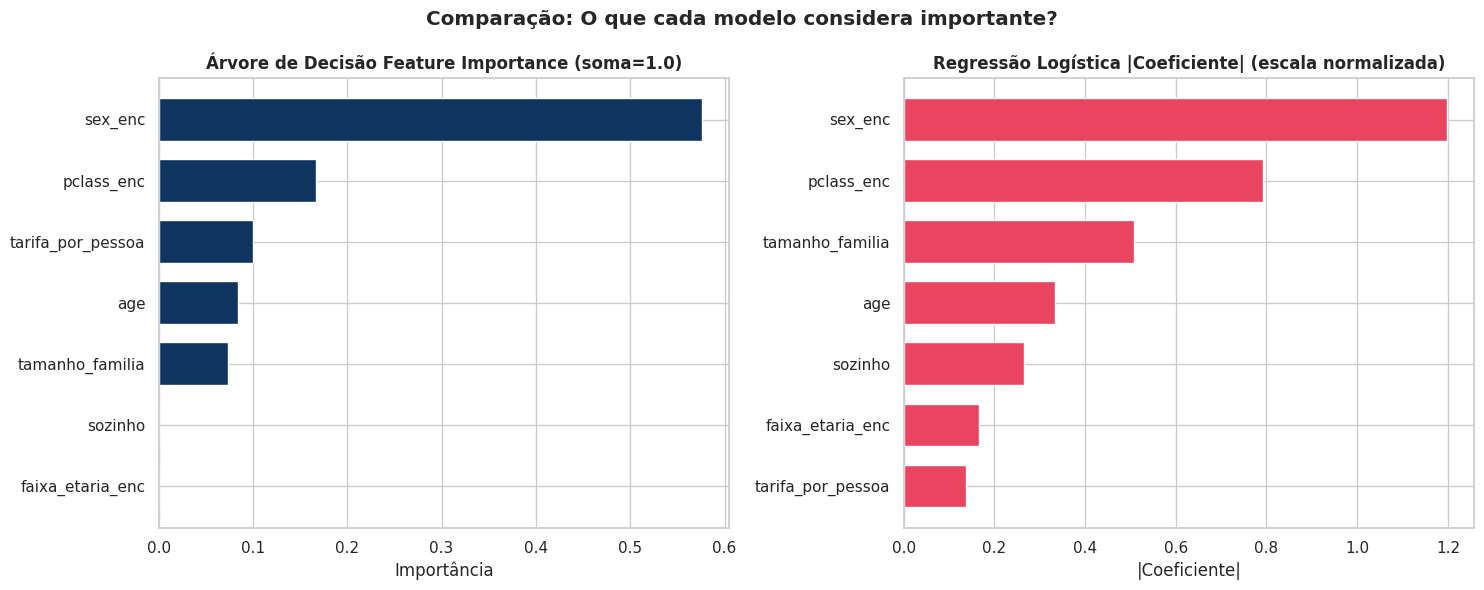

Os dois modelos concordam nos principais fatores?
As top features de cada modelo:
  Árvore:    ['sex_enc', 'pclass_enc', 'tarifa_por_pessoa']
  Log. Reg.: ['sex_enc', 'pclass_enc', 'tamanho_familia']


In [55]:
# Comparação: Feature Importance da Árvore vs Coeficientes da Reg. Logística
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Comparação: O que cada modelo considera importante?",
             fontweight="bold")

# Árvore: importâncias
imp_ord = importancias.sort_values("importancia", ascending=True)
axes[0].barh(imp_ord["feature"], imp_ord["importancia"],
             color="#0f3460", edgecolor="white", height=0.7)
axes[0].set_title("Árvore de Decisão Feature Importance (soma=1.0)",
                  fontweight="bold")
axes[0].set_xlabel("Importância")

# Log. Reg.: coeficientes absolutos
coefs = pd.DataFrame({
    "feature":     FEATURES,
    "coeficiente": np.abs(lr_ref.coef_[0])
}).sort_values("coeficiente", ascending=True)
axes[1].barh(coefs["feature"], coefs["coeficiente"],
             color="#e94560", edgecolor="white", height=0.7)
axes[1].set_title("Regressão Logística |Coeficiente| (escala normalizada)",
                  fontweight="bold")
axes[1].set_xlabel("|Coeficiente|")

plt.tight_layout()
plt.savefig("aula08_comparacao_importancias.png", dpi=110, bbox_inches="tight")
plt.show()

print("Os dois modelos concordam nos principais fatores?")
print("As top features de cada modelo:")
print(f"  Árvore:    {importancias.head(3)['feature'].tolist()}")
print(f"  Log. Reg.: {coefs.sort_values('coeficiente',ascending=False).head(3)['feature'].tolist()}")


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 5 — Compare a Feature Importance da Árvore com os coeficientes da Regressão Logística e responda: (a) as top 3 features concordam entre os dois modelos? (b) existe alguma feature que a Árvore considera importante mas a Log. Reg. não (ou vice-versa)? (c) o que isso nos diz sobre como cada algoritmo 'vê' os dados?</span></div>

*✏️ (a) Top 3 concordam? `???`*

*✏️ (b) Divergência entre modelos: `???`*

*✏️ (c) Isso significa: `???`*


In [56]:
# PLACAR FINAL — Todos os 4 modelos
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

todos_modelos = {
    "KNN (K=7)":           (knn_ref,      X_teste_sc),
    "Reg. Logistica":      (lr_ref,       X_teste_sc),
    "SVM RBF":             (svm_ref,      X_teste_sc),
    "Arvore (otimizada)":  (arvore_final, X_teste_arr),
}

tabela_final = [metricas(nome, modelo, Xte, y_teste)
                for nome, (modelo, Xte) in todos_modelos.items()]
df_final = pd.DataFrame(tabela_final).set_index("Modelo")

print("PLACAR FINAL — KNN vs Reg. Logística vs SVM vs Árvore de Decisão")
print("=" * 72)
print(df_final.round(4).to_string())
print()
print("Melhor por métrica:")
for col in df_final.columns:
    vencedor = df_final[col].idxmax()
    val      = df_final[col].max()
    print(f"  {col:<12} -> {vencedor}  ({val:.4f})")


PLACAR FINAL — KNN vs Reg. Logística vs SVM vs Árvore de Decisão
                    Acurácia      F1  Recall  Precisão  AUC-ROC
Modelo                                                         
KNN (K=7)             0.8065  0.7656  0.7656    0.7656   0.8509
Reg. Logistica        0.7806  0.7258  0.7031    0.7500   0.8553
SVM RBF               0.8194  0.7667  0.7188    0.8214   0.8396
Arvore (otimizada)    0.8065  0.7692  0.7812    0.7576   0.8715

Melhor por métrica:
  Acurácia     -> SVM RBF  (0.8194)
  F1           -> Arvore (otimizada)  (0.7692)
  Recall       -> Arvore (otimizada)  (0.7812)
  Precisão     -> SVM RBF  (0.8214)
  AUC-ROC      -> Arvore (otimizada)  (0.8715)


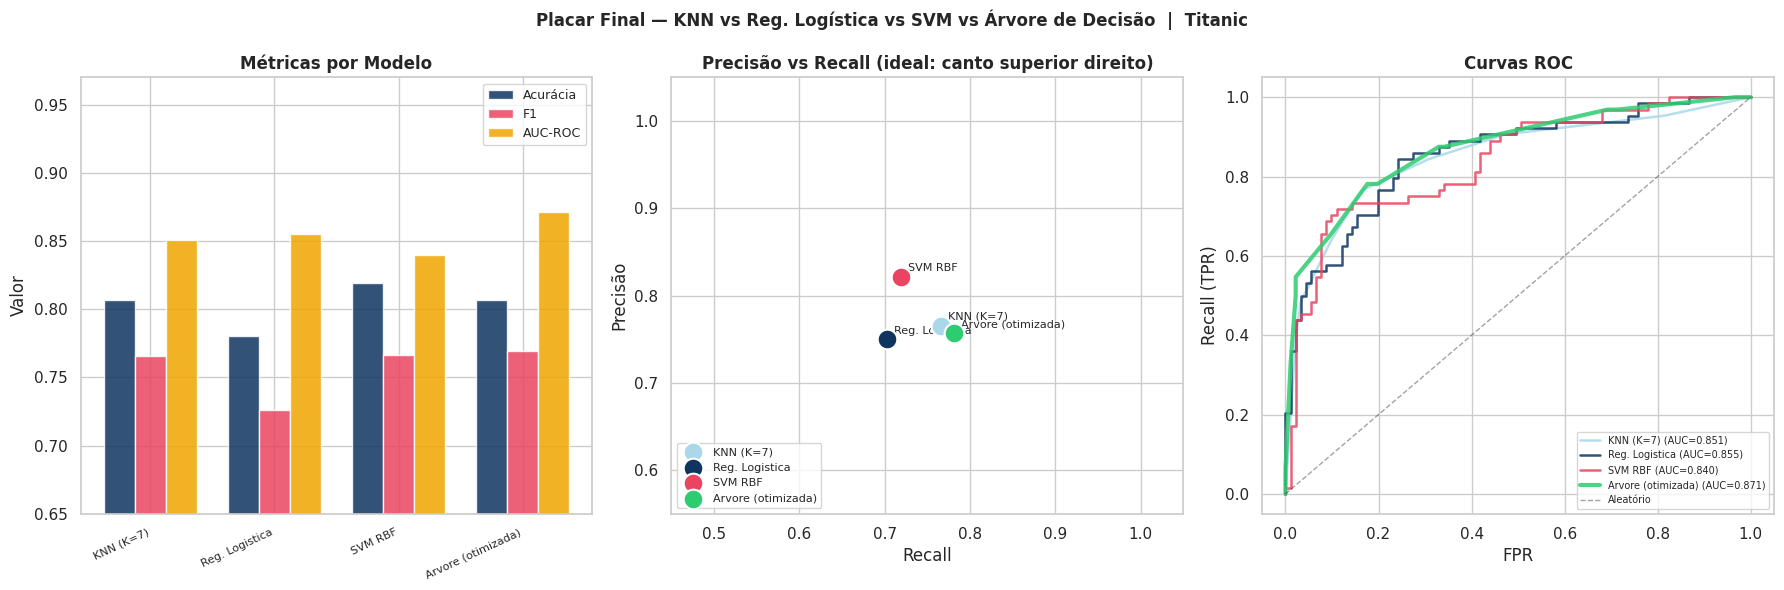

In [57]:
# Painel visual final completo
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Placar Final — KNN vs Reg. Logística vs SVM vs Árvore de Decisão  |  Titanic",
             fontsize=12, fontweight="bold")

CORES = ["#a8d8ea", "#0f3460", "#e94560", "#2ecc71"]
nomes = list(df_final.index)

# Gráfico 1: barras de métricas
metricas_plot = ["Acurácia", "F1", "AUC-ROC"]
x_pos = np.arange(len(nomes))
largura = 0.25
cores_m = ["#0f3460", "#e94560", "#f0a500"]

for i, (met, cor) in enumerate(zip(metricas_plot, cores_m)):
    axes[0].bar(x_pos + i*largura, df_final[met], width=largura,
                color=cor, edgecolor="white", alpha=0.85, label=met)

axes[0].set_xticks(x_pos + largura)
axes[0].set_xticklabels(nomes, rotation=25, ha="right", fontsize=8)
axes[0].set_ylabel("Valor"); axes[0].set_ylim(0.65, 0.97)
axes[0].set_title("Métricas por Modelo", fontweight="bold")
axes[0].legend(fontsize=9)

# Gráfico 2: Precisão vs Recall
for i, (nome, row) in enumerate(df_final.iterrows()):
    axes[1].scatter(row["Recall"], row["Precisão"],
                    s=200, color=CORES[i], zorder=5,
                    edgecolors="white", linewidth=1.5, label=nome)
    axes[1].annotate(nome, (row["Recall"], row["Precisão"]),
                     textcoords="offset points", xytext=(5, 4), fontsize=8)

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisão")
axes[1].set_title("Precisão vs Recall (ideal: canto superior direito)",
                  fontweight="bold")
axes[1].legend(fontsize=8, loc="lower left")
axes[1].set_xlim(0.45, 1.05); axes[1].set_ylim(0.55, 1.05)

# Gráfico 3: Curvas ROC
for i, (nome, (modelo, Xte)) in enumerate(todos_modelos.items()):
    ypr = modelo.predict_proba(Xte)[:,1]
    fpr, tpr, _ = roc_curve(y_teste, ypr)
    auc = roc_auc_score(y_teste, ypr)
    lw  = 3 if "Arvore" in nome else 1.8
    axes[2].plot(fpr, tpr, color=CORES[i], linewidth=lw,
                 label=f"{nome} (AUC={auc:.3f})", alpha=0.85)

axes[2].plot([0,1],[0,1],"k--",linewidth=1,alpha=0.4,label="Aleatório")
axes[2].set_xlabel("FPR"); axes[2].set_ylabel("Recall (TPR)")
axes[2].set_title("Curvas ROC", fontweight="bold")
axes[2].legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.savefig("aula08_placar_final.png", dpi=110, bbox_inches="tight")
plt.show()


In [58]:
# ── GABARITO DA MISSÃO 5 (descomente para ver) ───────────────────────────────
# top_arvore = importancias.head(3)["feature"].tolist()
# top_lr     = (pd.DataFrame({"feature": FEATURES,
#                              "coef": np.abs(lr_ref.coef_[0])})
#               .sort_values("coef", ascending=False).head(3)["feature"].tolist())
#
# print("Gabarito — Comparação de Feature Importance:")
# print()
# print(f"  Top 3 Arvore:    {top_arvore}")
# print(f"  Top 3 Log. Reg.: {top_lr}")
# print()
# concordam = set(top_arvore) & set(top_lr)
# print(f"  Concordam em: {concordam}")
# print()
# print("(b) Divergencias possiveis:")
# print("    A arvore captura interacoes nao-lineares entre features")
# print("    (ex: titulo_Mr e importante pq interage com classe e idade)")
# print("    A Log. Reg. ve cada feature de forma independente e linear.")
# print()
# print("(c) O que isso significa:")
# print("    Arvore: considera importante o que DIVIDE bem os dados")
# print("    Log. Reg.: considera importante o que tem CORRELACAO LINEAR com Y")
# print("    Uma feature pode ser importante para um e nao para o outro")
# print("    dependendo da natureza da relacao com o alvo.")


---

## Tabela Final — Quando Usar Cada Algoritmo

| Critério | KNN | Reg. Logística | SVM | Árvore de Decisão |
|----------|-----|---------------|-----|-------------------|
| **Explica cada decisão?** | Não | Parcial (coef.) | Não | **Sim — nó a nó** |
| **Fronteiras não-lineares** | Sim | Não | Sim (kernel) | Sim |
| **Precisa de normalização** | Sim | Recomendado | Sim | **Não** |
| **Lida com features mistas** | Com encoding | Com encoding | Com encoding | **Naturalmente** |
| **Overfitting se descuidar** | Sim (K pequeno) | Raramente | Sim (C alto) | **Sim (depth alto)** |
| **Velocidade de predição** | Lento | Muito rápido | Rápido | **Muito rápido** |
| **Base para modelos melhores** | Não | Não | Não | **Sim (RF, XGBoost)** |

<div style="background:#d4edda; border-left:5px solid #155724; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#155724;">✅ </strong><span style="color:#155724;">A Árvore de Decisão é a base do <strong>Random Forest</strong> e do <strong>Gradient Boosting (XGBoost, LightGBM)</strong> — os modelos mais usados em competições e produção com dados tabulares. Dominar a árvore individual é o pré-requisito essencial para a próxima aula.</span></div>

---

## Checklist — O que você sabe fazer agora

| Habilidade | Praticada hoje? |
|------------|----------------|
| Explicar como a árvore escolhe cada divisão (Gini / Entropia) | ☐ |
| Calcular o Ganho de Gini manualmente para uma divisão | ☐ |
| Treinar e visualizar uma Árvore de Decisão com scikit-learn | ☐ |
| Rastrear o caminho de decisão para um exemplo individual | ☐ |
| Identificar e controlar overfitting com `max_depth` | ☐ |
| Interpretar o gráfico de Feature Importance | ☐ |
| Comparar Feature Importance com coeficientes da Reg. Logística | ☐ |
| Comparar os 4 modelos do curso com métricas e curva ROC | ☐ |

---


## Reflexão final

<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">Escreva em suas próprias palavras: (1) por que a Árvore de Decisão é chamada de modelo 'caixa-branca'?, (2) qual é o maior risco de uma árvore sem limitação de profundidade?, (3) em qual situação real você preferiria uma Árvore de Decisão a um SVM?</span></div>


**✏️ Minha reflexão:**

1. Caixa-branca significa: *...*

2. Maior risco sem limitação de profundidade: *...*

3. Preferiria Árvore em vez de SVM quando: *...*


---

## O que vem a seguir?

```
Concluídos:  KNN ✅  Reg. Logística ✅  SVM ✅  Árvore de Decisão ✅
Próximos:    Random Forest  →  Gradient Boosting (XGBoost)
```

Na próxima aula você vai descobrir por que **juntar centenas de árvores**
produz um modelo muito mais poderoso do que qualquer árvore individual.
Esse é o conceito de **Ensemble** — e o Random Forest é sua primeira aplicação.

---

## Referências

- Scikit-Learn Decision Trees: https://scikit-learn.org/stable/modules/tree.html
- Breiman, L. et al. (1984). *Classification and Regression Trees*. Wadsworth.
- Géron, A. (2019). *Hands-on Machine Learning*, Cap. 6. O'Reilly.
- Quinlan, J.R. (1986). *Induction of Decision Trees*. Machine Learning, 1, 81–106.
